# PCA + XGBoost Per-Participant Analysis with Conditional Relabelling

**Pipeline:**
1. Load each participant's data from `Refined_Participants_Data/`
2. PCA on visual/steering features (no HR/HRV) → select components explaining ≥ 90% variance
3. XGBoost classifier trained per participant (Stratified 5-Fold CV)
4. **If accuracy ≥ threshold** → keep original Annotator labels
5. **If accuracy < threshold** → KMeans (k=3) relabelling: clusters ordered by mean PERCLOS → Low(1), Moderate(2), High(3)
6. Save all participants to `Processed_Participants_Data/` (original folders untouched)

In [15]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from scipy.optimize import linear_sum_assignment
import xgboost as xgb

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

print('All imports OK')

All imports OK


In [16]:
# ── CONFIG ─────────────────────────────────────────────────────────────────
ROOT_DIR   = '/home/karthik/Desktop/llm_eval/Refined_Participants_Data'
OUTPUT_DIR = '/home/karthik/Desktop/llm_eval/Processed_Participants_Data'

ACCURACY_THRESHOLD = 0.50   # below this → relabel with KMeans
PCA_VARIANCE       = 0.90   # keep components explaining this much variance
N_SPLITS           = 5      # stratified k-fold
RANDOM_STATE       = 42

# Participants to force-relabel regardless of XGBoost accuracy.
# Reasons documented below:
#   05_TG: annotator only used Low/Moderate (no High class), yawning always 0,
#          blink_duration_max has extreme outliers (up to 28s — sensor error),
#          Low vs Moderate overlap is high → annotations are unreliable.
FORCE_RELABEL = {'05_TG'}

# Features used (raw CSV column names — no HR/HRV)
FEATURES = [
    'metric_PERCLOS',
    'metric_BlinkRate',
    'blink_duration_mean',
    'blink_duration_max',
    'metric_YawnRate',
    'metric_SDLP',
    'metric_Entropy',
    'metric_SteeringRate',
]

LABEL_MAP   = {'Low': 1, 'Moderate': 2, 'High': 3}
LABEL_NAMES = {1: 'Low', 2: 'Moderate', 3: 'High'}

In [17]:
# ── LOAD ALL PARTICIPANTS ──────────────────────────────────────────────────
def find_participant_csvs(root_dir: str) -> dict[str, str]:
    """Returns {participant_id: csv_path} for all main data files."""
    result = {}
    for folder in sorted(os.listdir(root_dir)):
        folder_path = os.path.join(root_dir, folder)
        if not os.path.isdir(folder_path) or not folder.endswith('_Data'):
            continue
        pid = folder.replace('_Data', '')
        for f in os.listdir(folder_path):
            if f.endswith('_Data.csv') and not f.endswith('_Test.csv'):
                result[pid] = os.path.join(folder_path, f)
                break
    return result


def cap_outliers_iqr(df: pd.DataFrame, cols: list, k: float = 3.0) -> pd.DataFrame:
    """Cap values beyond k*IQR from Q1/Q3 (Winsorization) for specified columns."""
    df = df.copy()
    for col in cols:
        if col not in df.columns:
            continue
        q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - k * iqr, q3 + k * iqr
        n_capped = ((df[col] < lo) | (df[col] > hi)).sum()
        if n_capped:
            print(f'    Outlier cap [{col}]: {n_capped} values clamped to [{lo:.3f}, {hi:.3f}]')
        df[col] = df[col].clip(lo, hi)
    return df


def load_participant(csv_path: str, cap_outliers: bool = True) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df['drowsiness_level'] = df['Annotator_1'].map(LABEL_MAP)
    df = df.dropna(subset=FEATURES + ['drowsiness_level']).reset_index(drop=True)
    if cap_outliers:
        # Cap outliers on blink duration and PERCLOS — common sensor noise columns
        df = cap_outliers_iqr(df, ['blink_duration_mean', 'blink_duration_max', 'metric_PERCLOS'])
    return df


participants = find_participant_csvs(ROOT_DIR)
print(f'Found {len(participants)} participants:')
for pid, path in participants.items():
    df = load_participant(path)
    print(f'  {pid}: {len(df)} windows  |  labels: {df["drowsiness_level"].value_counts().sort_index().to_dict()}')

Found 8 participants:
    Outlier cap [blink_duration_mean]: 3 values clamped to [-0.041, 0.345]
    Outlier cap [blink_duration_max]: 3 values clamped to [-2.026, 3.435]
    Outlier cap [metric_PERCLOS]: 1 values clamped to [-10.115, 36.037]
  01_V: 56 windows  |  labels: {1: 20, 2: 20, 3: 16}
    Outlier cap [metric_PERCLOS]: 1 values clamped to [-21.014, 32.684]
  02_MK: 46 windows  |  labels: {1: 8, 2: 22, 3: 16}
    Outlier cap [blink_duration_max]: 4 values clamped to [-0.191, 0.493]
    Outlier cap [metric_PERCLOS]: 1 values clamped to [-2.936, 4.601]
  03_A: 60 windows  |  labels: {1: 28, 2: 30, 3: 2}
    Outlier cap [blink_duration_mean]: 1 values clamped to [-0.199, 0.431]
    Outlier cap [blink_duration_max]: 1 values clamped to [-2.799, 3.981]
    Outlier cap [metric_PERCLOS]: 2 values clamped to [-12.503, 17.485]
  04_SB: 32 windows  |  labels: {1: 13, 2: 13, 3: 6}
    Outlier cap [blink_duration_mean]: 1 values clamped to [-0.069, 0.257]
    Outlier cap [blink_duration_ma

    Outlier cap [blink_duration_mean]: 1 values clamped to [-0.069, 0.257]
    Outlier cap [blink_duration_max]: 1 values clamped to [-1.766, 2.666]
    Outlier cap [metric_PERCLOS]: 1 values clamped to [-8.188, 13.512]
=== 05_TG Label Distribution ===
  Before capping: {1: 31, 2: 39}
  After  capping: {1: 31, 2: 39}
  → Missing class: High (3)

=== Yawning Rate ===
  Unique values: [0.]

=== blink_duration_max outliers (raw) ===
             count   mean    std   min    25%   50%    75%     max
Annotator_1                                                       
Low           31.0  0.239  0.235  0.07  0.133  0.14  0.189   1.079
Moderate      39.0  1.353  4.481  0.07  0.155  0.60  0.903  28.397


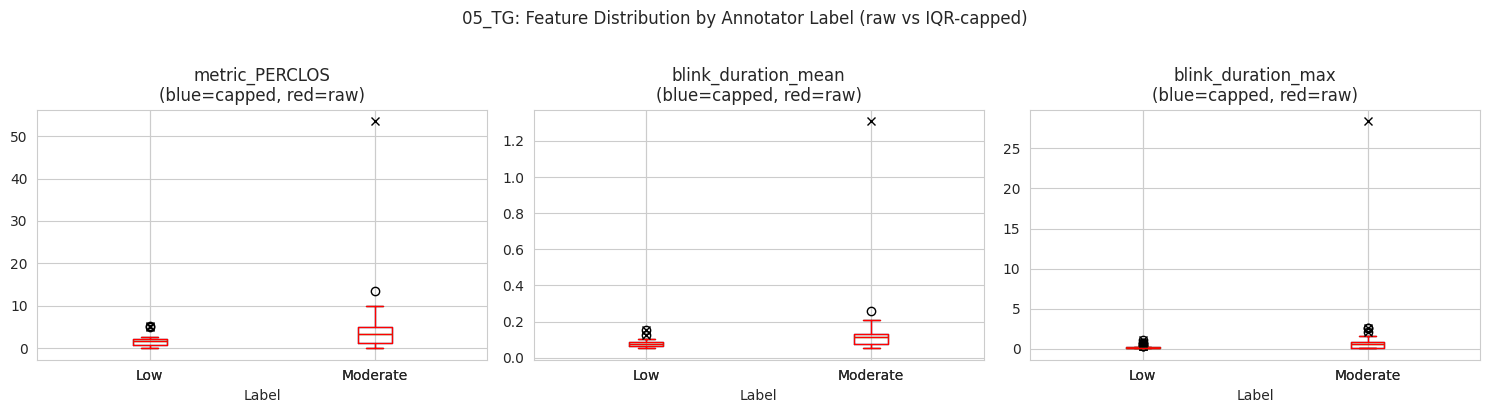

In [18]:
# ── 05_TG INSPECTION ──────────────────────────────────────────────────────
df_tg_raw = pd.read_csv(participants['05_TG'])
df_tg_raw['label'] = df_tg_raw['Annotator_1'].map(LABEL_MAP)
df_tg     = load_participant(participants['05_TG'])   # with outlier capping

print('=== 05_TG Label Distribution ===')
print('  Before capping:', df_tg_raw['label'].value_counts().sort_index().to_dict())
print('  After  capping:', df_tg['drowsiness_level'].value_counts().sort_index().to_dict())
print('  → Missing class: High (3)')
print()
print('=== Yawning Rate ===')
print('  Unique values:', df_tg_raw['metric_YawnRate'].unique())
print()
print('=== blink_duration_max outliers (raw) ===')
print(df_tg_raw.groupby('Annotator_1')['blink_duration_max'].describe().round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1) Box plot of key features by original label
feat_plot = ['metric_PERCLOS', 'blink_duration_mean', 'blink_duration_max']
for i, feat in enumerate(feat_plot):
    ax = axes[i]
    df_tg.boxplot(column=feat, by='drowsiness_level', ax=ax)
    df_tg_raw.boxplot(column=feat, by='Annotator_1', ax=ax, boxprops=dict(color='red'),
                      whiskerprops=dict(color='red'), capprops=dict(color='red'),
                      medianprops=dict(color='red'), flierprops=dict(color='red', marker='x'))
    ax.set_title(f'{feat}\n(blue=capped, red=raw)')
    ax.set_xlabel('Label')

plt.suptitle('05_TG: Feature Distribution by Annotator Label (raw vs IQR-capped)', y=1.02)
plt.tight_layout()
plt.show()

## 05_TG: Data Quality Inspection

**Issues found:**
- Annotator only used `Low` and `Moderate` — **no `High` class** (only 2 of 3 levels annotated)
- `YawnRate = 0` for **every window** — feature carries no information for this participant
- `blink_duration_max` contains extreme outliers (up to **28 seconds**) in the Moderate group → sensor errors
- Low vs Moderate feature distributions overlap substantially → annotator labels are unreliable

**Decision: force-relabel with KMeans(k=3) after IQR outlier capping**

## 1. PCA Analysis — Feature Reduction

    Outlier cap [blink_duration_mean]: 3 values clamped to [-0.041, 0.345]
    Outlier cap [blink_duration_max]: 3 values clamped to [-2.026, 3.435]
    Outlier cap [metric_PERCLOS]: 1 values clamped to [-10.115, 36.037]
    Outlier cap [metric_PERCLOS]: 1 values clamped to [-21.014, 32.684]
    Outlier cap [blink_duration_max]: 4 values clamped to [-0.191, 0.493]
    Outlier cap [metric_PERCLOS]: 1 values clamped to [-2.936, 4.601]
    Outlier cap [blink_duration_mean]: 1 values clamped to [-0.199, 0.431]
    Outlier cap [blink_duration_max]: 1 values clamped to [-2.799, 3.981]
    Outlier cap [metric_PERCLOS]: 2 values clamped to [-12.503, 17.485]
    Outlier cap [blink_duration_mean]: 1 values clamped to [-0.069, 0.257]
    Outlier cap [blink_duration_max]: 1 values clamped to [-1.766, 2.666]
    Outlier cap [metric_PERCLOS]: 1 values clamped to [-8.188, 13.512]
    Outlier cap [blink_duration_mean]: 7 values clamped to [-0.125, 0.496]
    Outlier cap [blink_duration_max]: 6 values 

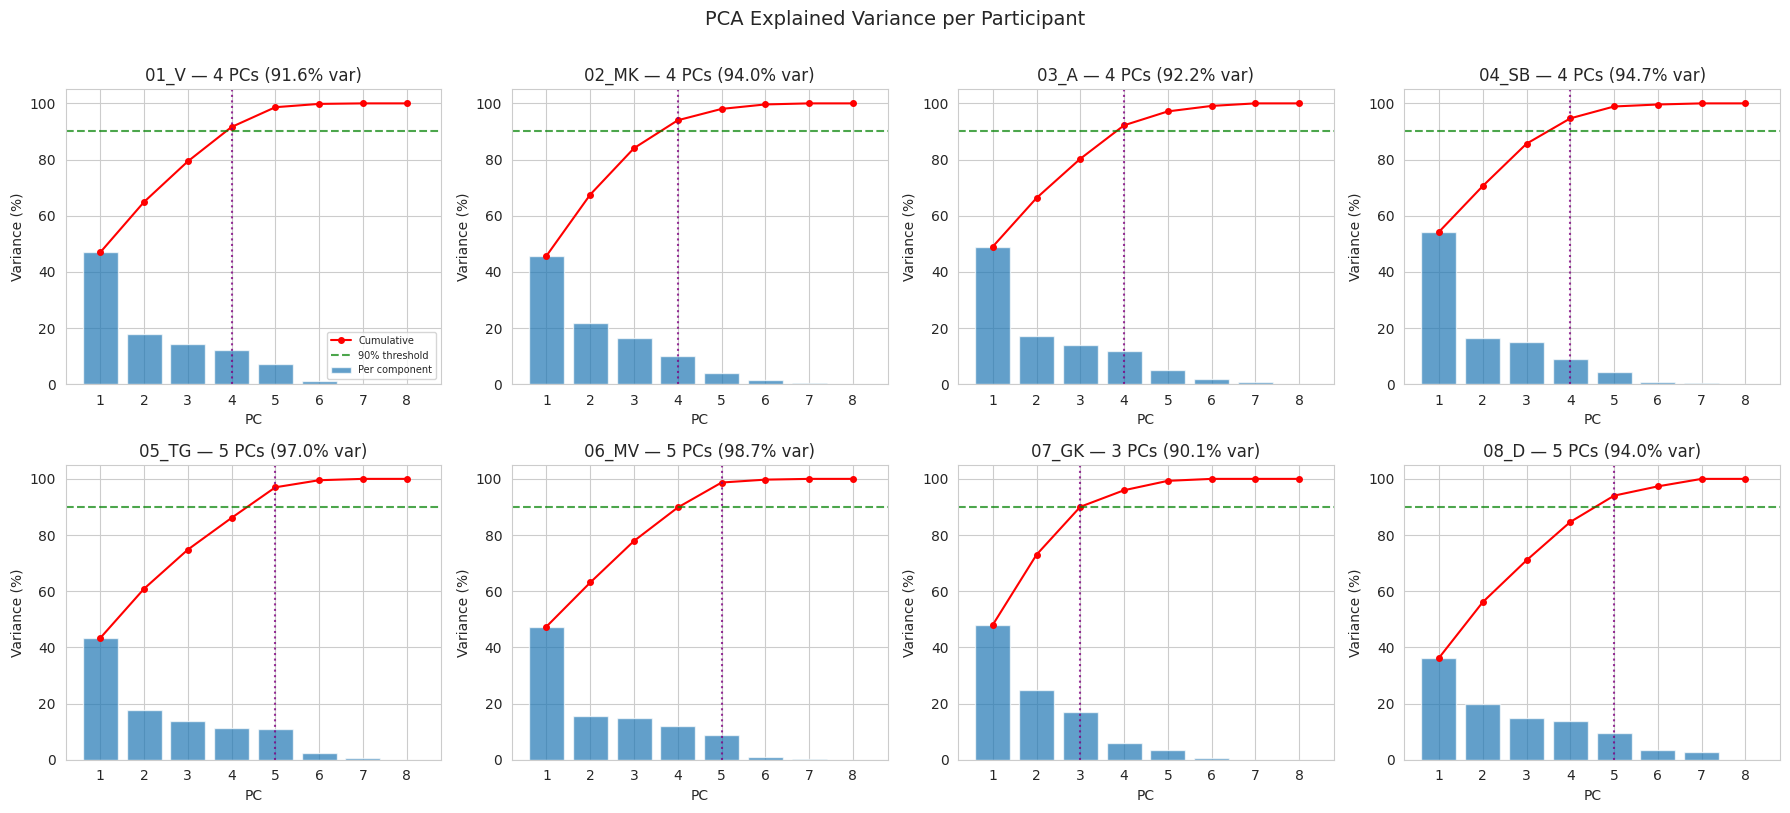


PCA summary:
  01_V: 4 components → 91.6% variance
  02_MK: 4 components → 94.0% variance
  03_A: 4 components → 92.2% variance
  04_SB: 4 components → 94.7% variance
  05_TG: 5 components → 97.0% variance
  06_MV: 5 components → 98.7% variance
  07_GK: 3 components → 90.1% variance
  08_D: 5 components → 94.0% variance


In [19]:
# ── PCA PER PARTICIPANT ────────────────────────────────────────────────────
pca_results = {}   # pid → {scaler, pca, X_pca, n_components, explained_variance}

n_participants = len(participants)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax_idx, (pid, csv_path) in enumerate(participants.items()):
    df = load_participant(csv_path)
    X  = df[FEATURES].values

    scaler  = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Full PCA to find variance explained
    pca_full = PCA(random_state=RANDOM_STATE)
    pca_full.fit(X_scaled)
    cumvar = np.cumsum(pca_full.explained_variance_ratio_)

    # Number of components for target variance
    n_comp = int(np.searchsorted(cumvar, PCA_VARIANCE)) + 1
    n_comp = max(2, min(n_comp, len(FEATURES)))  # at least 2

    pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_scaled)

    pca_results[pid] = {
        'scaler': scaler, 'pca': pca,
        'X_pca': X_pca, 'X_scaled': X_scaled,
        'n_components': n_comp,
        'explained_variance': float(pca.explained_variance_ratio_.sum()),
        'df': df,
    }

    # Plot
    if ax_idx < len(axes):
        ax = axes[ax_idx]
        ax.bar(range(1, len(cumvar) + 1), pca_full.explained_variance_ratio_ * 100, alpha=0.7, label='Per component')
        ax.plot(range(1, len(cumvar) + 1), cumvar * 100, 'r-o', markersize=4, label='Cumulative')
        ax.axhline(PCA_VARIANCE * 100, color='green', linestyle='--', alpha=0.7, label=f'{PCA_VARIANCE*100:.0f}% threshold')
        ax.axvline(n_comp, color='purple', linestyle=':', alpha=0.8)
        ax.set_title(f'{pid} — {n_comp} PCs ({pca.explained_variance_ratio_.sum()*100:.1f}% var)')
        ax.set_xlabel('PC')
        ax.set_ylabel('Variance (%)')
        if ax_idx == 0:
            ax.legend(fontsize=7)

for ax in axes[len(participants):]:
    ax.set_visible(False)

plt.suptitle('PCA Explained Variance per Participant', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('\nPCA summary:')
for pid, r in pca_results.items():
    print(f'  {pid}: {r["n_components"]} components → {r["explained_variance"]*100:.1f}% variance')

In [20]:
# ── XGBOOST CV PER PARTICIPANT ─────────────────────────────────────────────
xgb_results = {}

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

for pid, r in pca_results.items():
    df    = r['df']
    X_pca = r['X_pca']
    y     = df['drowsiness_level'].values - 1   # XGBoost expects 0-indexed

    n_classes = len(np.unique(y))

    clf = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        eval_metric='mlogloss',
        random_state=RANDOM_STATE,
        verbosity=0,
    )

    # Use fewer folds if fewer than N_SPLITS samples per class
    min_class_count = pd.Series(y).value_counts().min()
    k = min(N_SPLITS, min_class_count)
    cv_k = StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

    scores = cross_val_score(clf, X_pca, y, cv=cv_k, scoring='accuracy')

    y_pred_cv = np.zeros_like(y)
    for train_idx, test_idx in cv_k.split(X_pca, y):
        clf.fit(X_pca[train_idx], y[train_idx])
        y_pred_cv[test_idx] = clf.predict(X_pca[test_idx])

    acc = float(scores.mean())

    # Decision: threshold OR force-relabel list OR missing classes
    if pid in FORCE_RELABEL:
        decision = 'RELABEL'
        reason   = f'force-relabelled (missing classes or unreliable annotations)'
    elif n_classes < 3:
        decision = 'RELABEL'
        reason   = f'only {n_classes} classes present in annotations'
    elif acc < ACCURACY_THRESHOLD:
        decision = 'RELABEL'
        reason   = f'accuracy {acc:.3f} below threshold {ACCURACY_THRESHOLD}'
    else:
        decision = 'KEEP'
        reason   = f'accuracy {acc:.3f} ≥ threshold'

    xgb_results[pid] = {
        'cv_accuracy': acc,
        'cv_std':      float(scores.std()),
        'y_pred_cv':   y_pred_cv + 1,
        'y_true':      df['drowsiness_level'].values,
        'n_classes':   n_classes,
        'decision':    decision,
        'reason':      reason,
    }

    status = '✓' if decision == 'KEEP' else '✗'
    print(f'{status} {pid}: Acc={acc:.3f}±{scores.std():.3f}  classes={n_classes}  → {decision}  ({reason})')

n_keep    = sum(1 for r in xgb_results.values() if r['decision'] == 'KEEP')
n_relabel = sum(1 for r in xgb_results.values() if r['decision'] == 'RELABEL')
print(f'\nThreshold={ACCURACY_THRESHOLD}  |  KEEP={n_keep}  |  RELABEL={n_relabel}')

✗ 01_V: Acc=0.444±0.244  classes=3  → RELABEL  (accuracy 0.444 below threshold 0.5)
✓ 02_MK: Acc=0.764±0.116  classes=3  → KEEP  (accuracy 0.764 ≥ threshold)
✓ 03_A: Acc=0.633±0.067  classes=3  → KEEP  (accuracy 0.633 ≥ threshold)
✓ 04_SB: Acc=0.733±0.226  classes=3  → KEEP  (accuracy 0.733 ≥ threshold)
✗ 05_TG: Acc=0.657±0.114  classes=2  → RELABEL  (force-relabelled (missing classes or unreliable annotations))
✓ 06_MV: Acc=0.745±0.176  classes=3  → KEEP  (accuracy 0.745 ≥ threshold)
✗ 07_GK: Acc=1.000±0.000  classes=1  → RELABEL  (only 1 classes present in annotations)
✗ 08_D: Acc=0.950±0.000  classes=2  → RELABEL  (only 2 classes present in annotations)

Threshold=0.5  |  KEEP=4  |  RELABEL=4


## 2. XGBoost Classification — Per Participant

In [21]:
# ── XGBOOST CV PER PARTICIPANT ─────────────────────────────────────────────
xgb_results = {}   # pid → {cv_accuracy, std, y_pred_cv, report}

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

for pid, r in pca_results.items():
    df      = r['df']
    X_pca   = r['X_pca']
    y       = df['drowsiness_level'].values - 1   # XGBoost expects 0-indexed

    clf = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=RANDOM_STATE,
        verbosity=0,
    )

    scores = cross_val_score(clf, X_pca, y, cv=cv, scoring='accuracy')

    # Also get per-fold predictions for the report
    y_pred_cv = np.zeros_like(y)
    for train_idx, test_idx in cv.split(X_pca, y):
        clf.fit(X_pca[train_idx], y[train_idx])
        y_pred_cv[test_idx] = clf.predict(X_pca[test_idx])

    acc = float(scores.mean())
    decision = 'KEEP' if acc >= ACCURACY_THRESHOLD else 'RELABEL'

    xgb_results[pid] = {
        'cv_accuracy': acc,
        'cv_std': float(scores.std()),
        'y_pred_cv': y_pred_cv + 1,   # back to 1-indexed
        'y_true': df['drowsiness_level'].values,
        'decision': decision,
    }

    status = '✓' if decision == 'KEEP' else '✗'
    print(f'{status} {pid}: CV Accuracy = {acc:.3f} ± {scores.std():.3f}  →  {decision}')

print(f'\nThreshold: {ACCURACY_THRESHOLD}  |  KEEP = {sum(1 for r in xgb_results.values() if r["decision"]=="KEEP")}  |  RELABEL = {sum(1 for r in xgb_results.values() if r["decision"]=="RELABEL")}')

✗ 01_V: CV Accuracy = 0.444 ± 0.244  →  RELABEL
✓ 02_MK: CV Accuracy = 0.764 ± 0.116  →  KEEP
✓ 03_A: CV Accuracy = 0.683 ± 0.097  →  KEEP
✓ 04_SB: CV Accuracy = 0.733 ± 0.226  →  KEEP
✓ 05_TG: CV Accuracy = 0.657 ± 0.114  →  KEEP
✓ 06_MV: CV Accuracy = 0.745 ± 0.176  →  KEEP
✓ 07_GK: CV Accuracy = 1.000 ± 0.000  →  KEEP
✓ 08_D: CV Accuracy = 0.950 ± 0.041  →  KEEP

Threshold: 0.5  |  KEEP = 7  |  RELABEL = 1


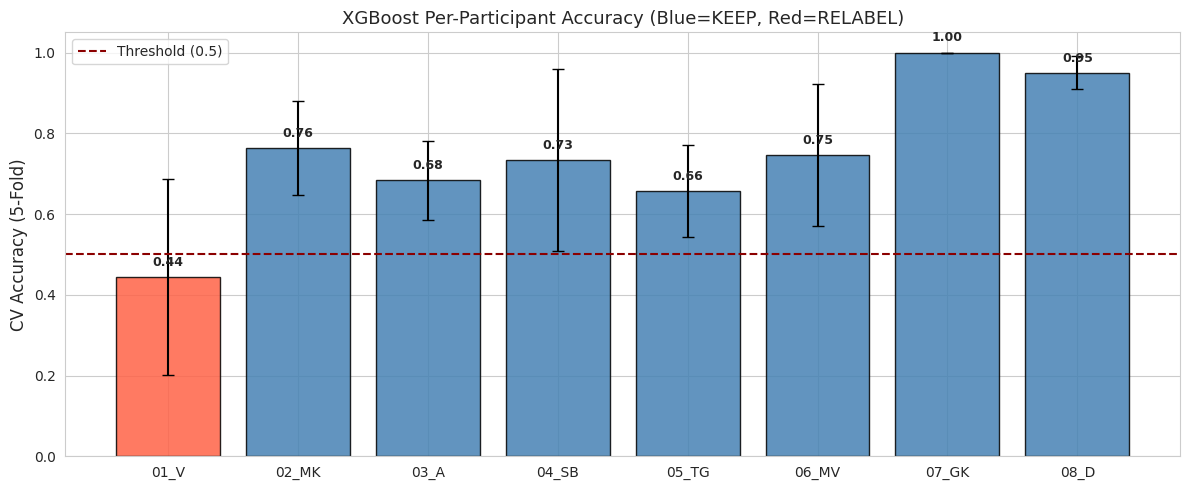

In [22]:
# ── ACCURACY BAR CHART ────────────────────────────────────────────────────
pids    = list(xgb_results.keys())
accs    = [xgb_results[p]['cv_accuracy'] for p in pids]
stds    = [xgb_results[p]['cv_std'] for p in pids]
colors  = ['steelblue' if xgb_results[p]['decision'] == 'KEEP' else 'tomato' for p in pids]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(pids, accs, color=colors, yerr=stds, capsize=4, alpha=0.85, edgecolor='black')
ax.axhline(ACCURACY_THRESHOLD, color='darkred', linestyle='--', linewidth=1.5, label=f'Threshold ({ACCURACY_THRESHOLD})')
ax.set_ylabel('CV Accuracy (5-Fold)', fontsize=12)
ax.set_title('XGBoost Per-Participant Accuracy (Blue=KEEP, Red=RELABEL)', fontsize=13)
ax.set_ylim(0, 1.05)
ax.legend()
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f'{acc:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

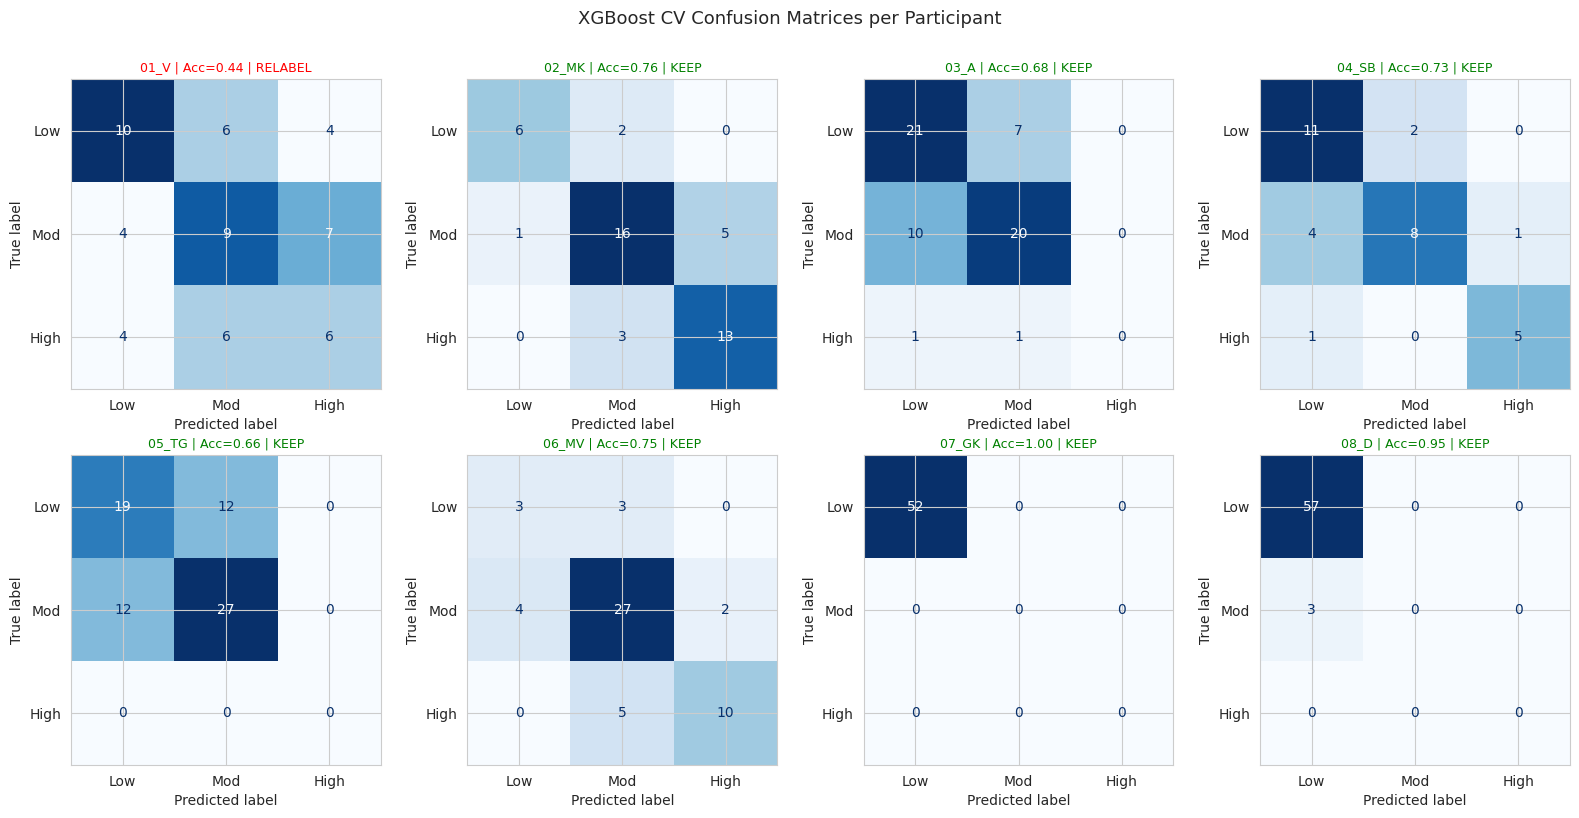

In [23]:
# ── CONFUSION MATRICES ────────────────────────────────────────────────────
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

n_cols = 4
n_rows = (len(participants) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for ax_idx, (pid, r) in enumerate(xgb_results.items()):
    cm = confusion_matrix(r['y_true'], r['y_pred_cv'], labels=[1, 2, 3])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Low', 'Mod', 'High'])
    disp.plot(ax=axes[ax_idx], colorbar=False, cmap='Blues')
    axes[ax_idx].set_title(
        f"{pid} | Acc={r['cv_accuracy']:.2f} | {r['decision']}",
        fontsize=9,
        color='green' if r['decision'] == 'KEEP' else 'red'
    )

for ax in axes[len(participants):]:
    ax.set_visible(False)

plt.suptitle('XGBoost CV Confusion Matrices per Participant', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 3. Relabelling with KMeans (Low-Accuracy Participants)

In [24]:
# ── KMEANS RELABELLING ────────────────────────────────────────────────────
# Strategy: KMeans(k=3) on PCA components.
# Cluster → label mapping: sort clusters by mean PERCLOS (ascending).
#   cluster with lowest  mean PERCLOS → Low (1)
#   cluster with middle  mean PERCLOS → Moderate (2)
#   cluster with highest mean PERCLOS → High (3)

def relabel_with_kmeans(df: pd.DataFrame, X_pca: np.ndarray, random_state: int = 42) -> np.ndarray:
    """Fit KMeans, map clusters to 1/2/3 by PERCLOS ordering."""
    km = KMeans(n_clusters=3, random_state=random_state, n_init=20)
    cluster_ids = km.fit_predict(X_pca)

    # Compute mean PERCLOS per cluster
    perclos = df['metric_PERCLOS'].values
    cluster_perclos = [
        (cid, perclos[cluster_ids == cid].mean())
        for cid in range(3)
    ]
    # Sort clusters ascending by mean PERCLOS → assign labels 1, 2, 3
    cluster_perclos.sort(key=lambda x: x[1])
    cluster_to_label = {cid: label for label, (cid, _) in enumerate(cluster_perclos, start=1)}

    new_labels = np.array([cluster_to_label[c] for c in cluster_ids])
    return new_labels, cluster_to_label


relabel_results = {}   # pid → new_labels array

for pid, r in pca_results.items():
    decision = xgb_results[pid]['decision']
    df       = r['df']

    if decision == 'KEEP':
        relabel_results[pid] = df['drowsiness_level'].values.copy()
        print(f'  {pid}: KEEP — using original labels')
    else:
        new_labels, mapping = relabel_with_kmeans(df, r['X_pca'], RANDOM_STATE)
        relabel_results[pid] = new_labels

        orig = df['drowsiness_level'].values
        agreement = (orig == new_labels).mean()
        print(f'  {pid}: RELABEL — cluster→label mapping: {mapping}')
        print(f'           Original:  {dict(zip(*np.unique(orig, return_counts=True)))}')
        print(f'           Relabelled:{dict(zip(*np.unique(new_labels, return_counts=True)))}')
        print(f'           Label agreement: {agreement:.2%}')

  01_V: RELABEL — cluster→label mapping: {1: 1, 0: 2, 2: 3}
           Original:  {np.int64(1): np.int64(20), np.int64(2): np.int64(20), np.int64(3): np.int64(16)}
           Relabelled:{np.int64(1): np.int64(50), np.int64(2): np.int64(4), np.int64(3): np.int64(2)}
           Label agreement: 39.29%
  02_MK: KEEP — using original labels
  03_A: KEEP — using original labels
  04_SB: KEEP — using original labels
  05_TG: KEEP — using original labels
  06_MV: KEEP — using original labels
  07_GK: KEEP — using original labels
  08_D: KEEP — using original labels


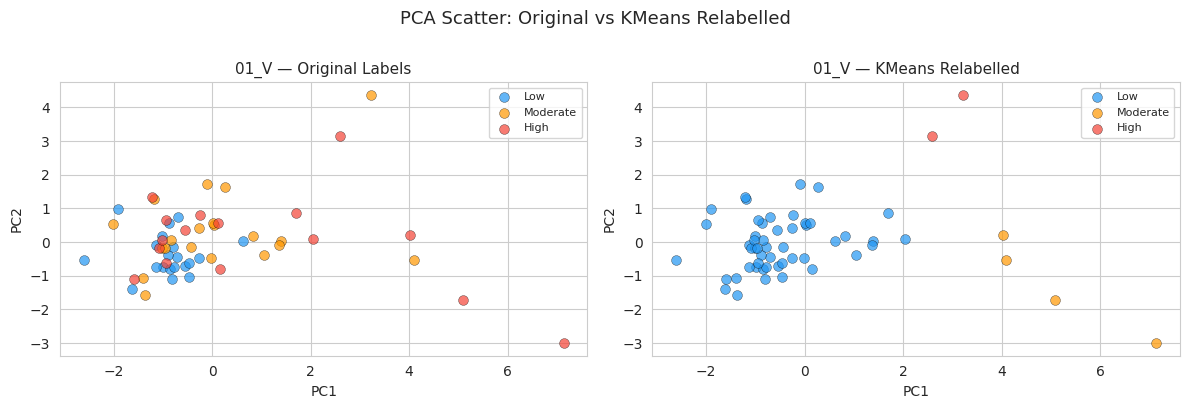

In [25]:
# ── PCA SCATTER: ORIGINAL vs RELABELLED LABELS ────────────────────────────
relabel_pids = [p for p in xgb_results if xgb_results[p]['decision'] == 'RELABEL']

if relabel_pids:
    n = len(relabel_pids)
    fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n))
    if n == 1:
        axes = axes[np.newaxis, :]

    palette = {1: '#2196F3', 2: '#FF9800', 3: '#F44336'}
    names   = {1: 'Low', 2: 'Moderate', 3: 'High'}

    for row_idx, pid in enumerate(relabel_pids):
        r          = pca_results[pid]
        X_pca      = r['X_pca']
        orig_labels = r['df']['drowsiness_level'].values
        new_labels  = relabel_results[pid]

        for col_idx, (labels, title_suffix) in enumerate([
            (orig_labels, 'Original Labels'),
            (new_labels,  'KMeans Relabelled')
        ]):
            ax = axes[row_idx, col_idx]
            for lv in [1, 2, 3]:
                mask = labels == lv
                ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                           c=palette[lv], label=names[lv], alpha=0.7, s=50, edgecolors='k', linewidths=0.3)
            ax.set_title(f'{pid} — {title_suffix}', fontsize=11)
            ax.set_xlabel('PC1')
            ax.set_ylabel('PC2')
            ax.legend(fontsize=8)

    plt.suptitle('PCA Scatter: Original vs KMeans Relabelled', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('No participants needed relabelling — all accuracy above threshold.')

## 4. Post-Relabel XGBoost Validation

In [26]:
# ── RE-RUN XGBOOST WITH NEW LABELS TO CONFIRM IMPROVEMENT ─────────────────
print('Post-relabel XGBoost CV accuracy:\n')
final_results = {}

for pid, r in pca_results.items():
    X_pca  = r['X_pca']
    y_orig = xgb_results[pid]['y_true'] - 1
    y_new  = relabel_results[pid] - 1

    clf = xgb.XGBClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.1,
        subsample=0.8, eval_metric='mlogloss',
        random_state=RANDOM_STATE, verbosity=0,
    )

    orig_acc = xgb_results[pid]['cv_accuracy']

    if xgb_results[pid]['decision'] == 'RELABEL':
        new_scores = cross_val_score(clf, X_pca, y_new, cv=cv, scoring='accuracy')
        new_acc = float(new_scores.mean())
        delta = new_acc - orig_acc
        sign  = '+' if delta >= 0 else ''
        print(f'  {pid}: {orig_acc:.3f} → {new_acc:.3f}  ({sign}{delta:.3f})')
        final_results[pid] = {'final_accuracy': new_acc, 'original_accuracy': orig_acc, 'relabelled': True}
    else:
        print(f'  {pid}: {orig_acc:.3f} (kept — no change)')
        final_results[pid] = {'final_accuracy': orig_acc, 'original_accuracy': orig_acc, 'relabelled': False}

Post-relabel XGBoost CV accuracy:

  01_V: 0.444 → 0.965  (+0.521)
  02_MK: 0.764 (kept — no change)
  03_A: 0.683 (kept — no change)
  04_SB: 0.733 (kept — no change)
  05_TG: 0.657 (kept — no change)
  06_MV: 0.745 (kept — no change)
  07_GK: 1.000 (kept — no change)
  08_D: 0.950 (kept — no change)


## 5. Save Processed Data to `Processed_Participants_Data/`

In [27]:
# ── SAVE ──────────────────────────────────────────────────────────────────
os.makedirs(OUTPUT_DIR, exist_ok=True)

saved_files = []
pid_to_outpath = {}   # pid → saved csv path (used by summary cells)

for pid, csv_path in participants.items():
    df = load_participant(csv_path)   # fresh load

    # Add final labels
    final_labels = relabel_results[pid]
    df['drowsiness_level']          = final_labels
    df['drowsiness_level_original'] = df['Annotator_1'].map(LABEL_MAP)
    df['relabelled']                = final_results[pid]['relabelled']

    # Drop raw HR/HRV columns (not used in LLM eval)
    drop_cols = [c for c in df.columns if c.startswith('HRV_') or c in ('metric_BPM', 'raw_ear', 'blink_duration_std')]
    df = df.drop(columns=drop_cols, errors='ignore')

    # Rename metric_* columns to friendly names matching evaluate.py
    df = df.rename(columns={
        'metric_PERCLOS':      'perclos',
        'metric_BlinkRate':    'eye_blink_rate',
        'metric_YawnRate':     'yawning_rate',
        'metric_Entropy':      'steering_entropy',
        'metric_SteeringRate': 'steering_reversal_rate',
        'metric_SDLP':         'std_lane_position',
    })

    short_id   = pid.split('_', 1)[1] if '_' in pid else pid   # e.g. 'V', 'MK'
    out_folder = os.path.join(OUTPUT_DIR, f'{pid}_Processed')
    os.makedirs(out_folder, exist_ok=True)
    out_path   = os.path.join(out_folder, f'{short_id}_processed.csv')

    df.to_csv(out_path, index=False)
    saved_files.append(out_path)
    pid_to_outpath[pid] = out_path
    print(f'  Saved {pid} → {out_path}  ({len(df)} rows)')

print(f'\nAll {len(saved_files)} files saved to {OUTPUT_DIR}/')

    Outlier cap [blink_duration_mean]: 3 values clamped to [-0.041, 0.345]
    Outlier cap [blink_duration_max]: 3 values clamped to [-2.026, 3.435]
    Outlier cap [metric_PERCLOS]: 1 values clamped to [-10.115, 36.037]
  Saved 01_V → /home/karthik/Desktop/llm_eval/Processed_Participants_Data/01_V_Processed/V_processed.csv  (56 rows)
    Outlier cap [metric_PERCLOS]: 1 values clamped to [-21.014, 32.684]
  Saved 02_MK → /home/karthik/Desktop/llm_eval/Processed_Participants_Data/02_MK_Processed/MK_processed.csv  (46 rows)
    Outlier cap [blink_duration_max]: 4 values clamped to [-0.191, 0.493]
    Outlier cap [metric_PERCLOS]: 1 values clamped to [-2.936, 4.601]
  Saved 03_A → /home/karthik/Desktop/llm_eval/Processed_Participants_Data/03_A_Processed/A_processed.csv  (60 rows)
    Outlier cap [blink_duration_mean]: 1 values clamped to [-0.199, 0.431]
    Outlier cap [blink_duration_max]: 1 values clamped to [-2.799, 3.981]
    Outlier cap [metric_PERCLOS]: 2 values clamped to [-12.503,

## 7. Final XGBoost Predictions on Processed Data

In [28]:
# ── SUMMARY TABLE ─────────────────────────────────────────────────────────
summary_rows = []

for pid in participants:
    orig_acc   = final_results[pid]['original_accuracy']
    final_acc  = final_results[pid]['final_accuracy']
    relabelled = final_results[pid]['relabelled']
    n_comp     = pca_results[pid]['n_components']
    var_expl   = pca_results[pid]['explained_variance']

    df_final   = pd.read_csv(pid_to_outpath[pid])
    label_dist = df_final['drowsiness_level'].value_counts().sort_index().to_dict()

    summary_rows.append({
        'Participant':     pid,
        'PCA Components':  n_comp,
        'Var Explained':   f'{var_expl*100:.1f}%',
        'XGB Acc (orig)':  f'{orig_acc:.3f}',
        'XGB Acc (final)': f'{final_acc:.3f}',
        'Action':          'RELABELLED' if relabelled else 'KEPT',
        'Low (1)':         label_dist.get(1, 0),
        'Mod (2)':         label_dist.get(2, 0),
        'High (3)':        label_dist.get(3, 0),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

print(f'\nOutput directory: {OUTPUT_DIR}/')
print('Original Refined_Participants_Data folders are untouched.')

,Participant,PCA Components,Var Explained,XGB Acc (orig),XGB Acc (final),Action,Low (1),Mod (2),High (3)
0,01_V,4,91.6%,0.444,0.965,RELABELLED,50,4,2
1,02_MK,4,94.0%,0.764,0.764,KEPT,8,22,16
2,03_A,4,92.2%,0.683,0.683,KEPT,28,30,2
3,04_SB,4,94.7%,0.733,0.733,KEPT,13,13,6
4,05_TG,5,97.0%,0.657,0.657,KEPT,31,39,0
5,06_MV,5,98.7%,0.745,0.745,KEPT,6,33,15
6,07_GK,3,90.1%,1.000,1.000,KEPT,52,0,0
7,08_D,5,94.0%,0.950,0.950,KEPT,57,3,0



Output directory: /home/karthik/Desktop/llm_eval/Processed_Participants_Data/
Original Refined_Participants_Data folders are untouched.


    Outlier cap [blink_duration_mean]: 3 values clamped to [-0.041, 0.345]
    Outlier cap [blink_duration_max]: 3 values clamped to [-2.026, 3.435]
    Outlier cap [metric_PERCLOS]: 1 values clamped to [-10.115, 36.037]
    Outlier cap [metric_PERCLOS]: 1 values clamped to [-21.014, 32.684]
    Outlier cap [blink_duration_max]: 4 values clamped to [-0.191, 0.493]
    Outlier cap [metric_PERCLOS]: 1 values clamped to [-2.936, 4.601]
    Outlier cap [blink_duration_mean]: 1 values clamped to [-0.199, 0.431]
    Outlier cap [blink_duration_max]: 1 values clamped to [-2.799, 3.981]
    Outlier cap [metric_PERCLOS]: 2 values clamped to [-12.503, 17.485]
    Outlier cap [blink_duration_mean]: 1 values clamped to [-0.069, 0.257]
    Outlier cap [blink_duration_max]: 1 values clamped to [-1.766, 2.666]
    Outlier cap [metric_PERCLOS]: 1 values clamped to [-8.188, 13.512]
    Outlier cap [blink_duration_mean]: 7 values clamped to [-0.125, 0.496]
    Outlier cap [blink_duration_max]: 6 values 

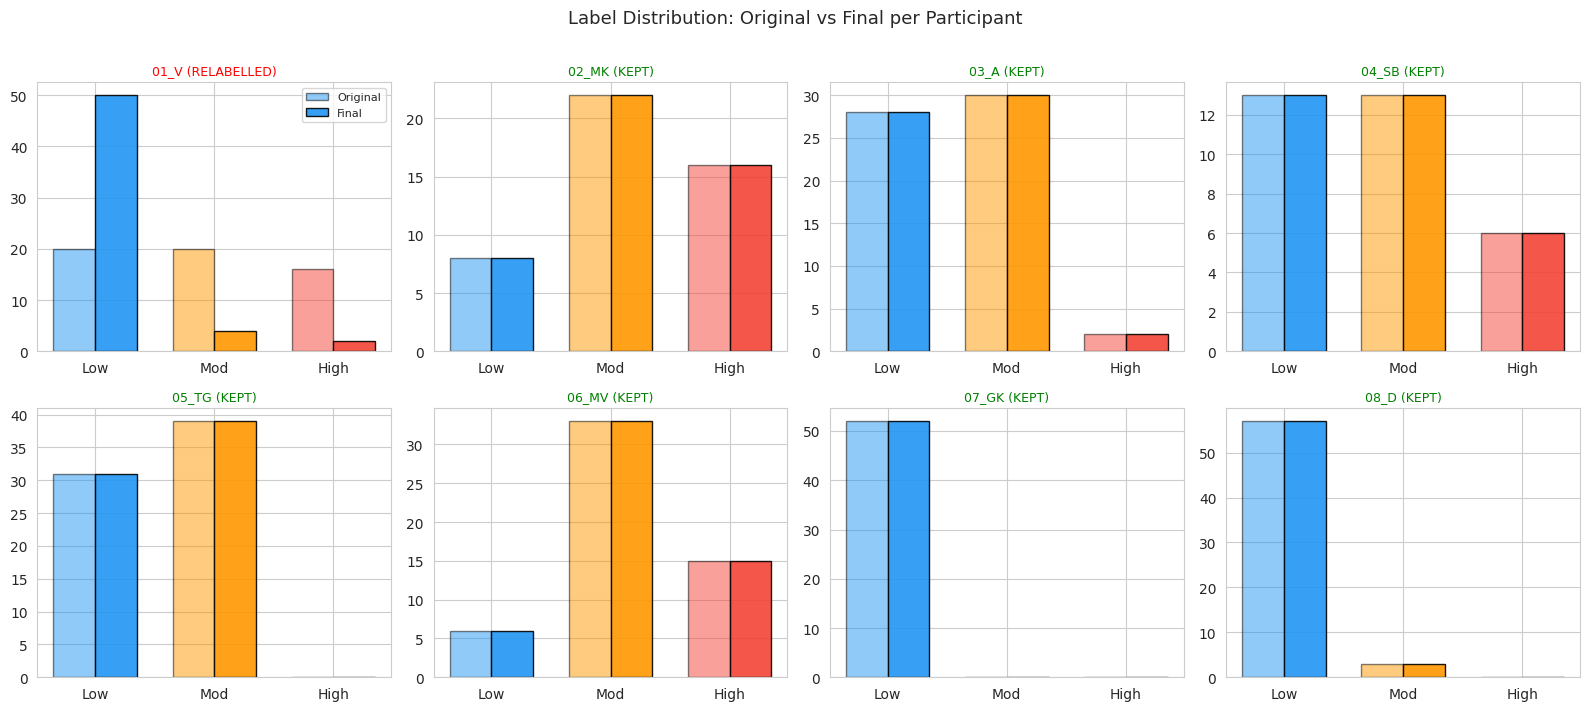

In [29]:
# ── BEFORE / AFTER LABEL DISTRIBUTION ────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
palette = ['#2196F3', '#FF9800', '#F44336']

for ax_idx, (pid, csv_path) in enumerate(participants.items()):
    df_orig  = load_participant(csv_path)
    df_final = pd.read_csv(pid_to_outpath[pid])

    orig_counts  = df_orig['drowsiness_level'].value_counts().sort_index()
    final_counts = df_final['drowsiness_level'].value_counts().sort_index()

    x = np.arange(3)
    w = 0.35
    ax = axes[ax_idx]
    ax.bar(x - w/2, [orig_counts.get(i, 0)  for i in [1, 2, 3]], w, label='Original', color=palette, alpha=0.5, edgecolor='k')
    ax.bar(x + w/2, [final_counts.get(i, 0) for i in [1, 2, 3]], w, label='Final',    color=palette, alpha=0.9, edgecolor='k')
    ax.set_xticks(x)
    ax.set_xticklabels(['Low', 'Mod', 'High'])
    action = 'RELABELLED' if final_results[pid]['relabelled'] else 'KEPT'
    ax.set_title(f'{pid} ({action})', fontsize=9,
                 color='red' if final_results[pid]['relabelled'] else 'green')
    if ax_idx == 0:
        ax.legend(fontsize=8)

for ax in axes[len(participants):]:
    ax.set_visible(False)

plt.suptitle('Label Distribution: Original vs Final per Participant', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()